# Experiment 3 – Model Comparison

Compare the performance of **Naïve Bayes and Decision Tree classifiers** using the same dataset.  
Visualize the comparison using **accuracy bar charts, ROC curves, and confusion matrix heatmaps**.

Naïve Bayes Training Accuracy: 0.9396984924623115
Naïve Bayes Testing Accuracy : 0.9415204678362573

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy : 0.9415204678362573


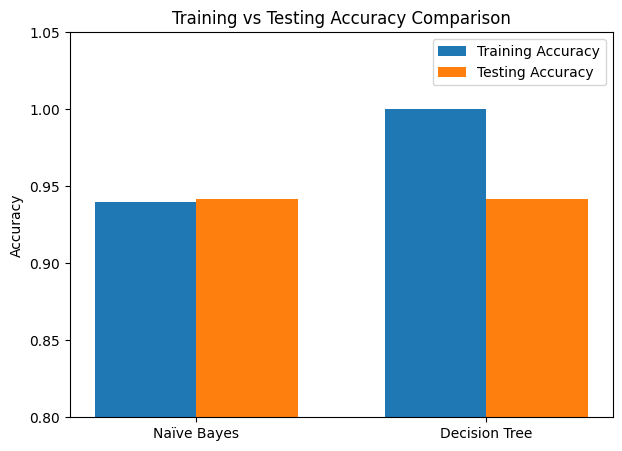

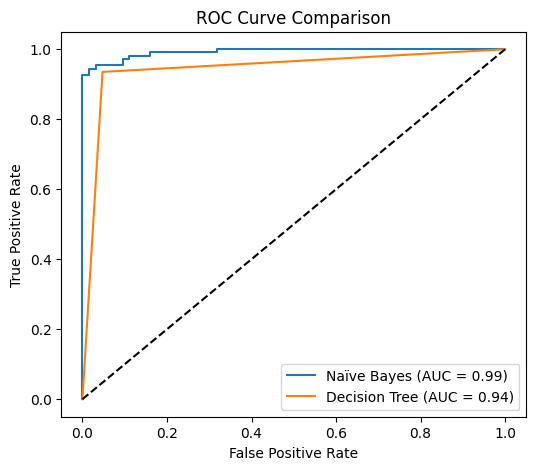

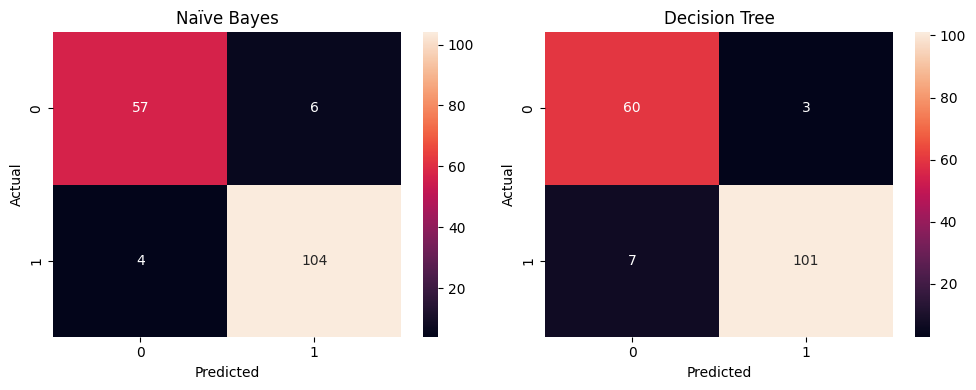

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc


data = load_breast_cancer()
X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Models
nb_model = GaussianNB()
dt_model = DecisionTreeClassifier(random_state=42)

nb_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# 5️⃣ Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Accuracy calculation
nb_train_acc = accuracy_score(y_train, nb_model.predict(X_train))
nb_test_acc  = accuracy_score(y_test, y_pred_nb)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc  = accuracy_score(y_test, y_pred_dt)

print("Naïve Bayes Training Accuracy:", nb_train_acc)
print("Naïve Bayes Testing Accuracy :", nb_test_acc)
print("\nDecision Tree Training Accuracy:", dt_train_acc)
print("Decision Tree Testing Accuracy :", dt_test_acc)

# Grouped Bar chart
models = ['Naïve Bayes', 'Decision Tree']
train_scores = [nb_train_acc, dt_train_acc]
test_scores  = [nb_test_acc, dt_test_acc]

x = np.arange(len(models))   # positions
width = 0.35                 # bar width

plt.figure(figsize=(7,5))
plt.bar(x - width/2, train_scores, width, label='Training Accuracy')
plt.bar(x + width/2, test_scores,  width, label='Testing Accuracy')

plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.xticks(x, models)
plt.legend()
plt.ylim(0.8, 1.05)  # makes comparison visually clear
plt.show()

# ROC curve comaprison
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_nb, tpr_nb, label="Naïve Bayes (AUC = %0.2f)" % roc_auc_nb)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = %0.2f)" % roc_auc_dt)
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion Matrix (side by side)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()